In [ ]:
import os
import cv2 as cv
import glob as gb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
train_dir = '../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_dir = '../input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
test_dir = '../input/new-plant-diseases-dataset/test/test'

In [ ]:
Size=224
X_test=[]
y_test=[]

In [ ]:
import tensorflow as tf

Size = 224  # Define the image size

train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    rescale=1/255.0,
    validation_split=0.1,
).flow_from_directory(
    train_dir,
    batch_size=16,
    target_size=(Size, Size),
    subset="training",
    shuffle=True
)

Found 63282 images belonging to 38 classes.


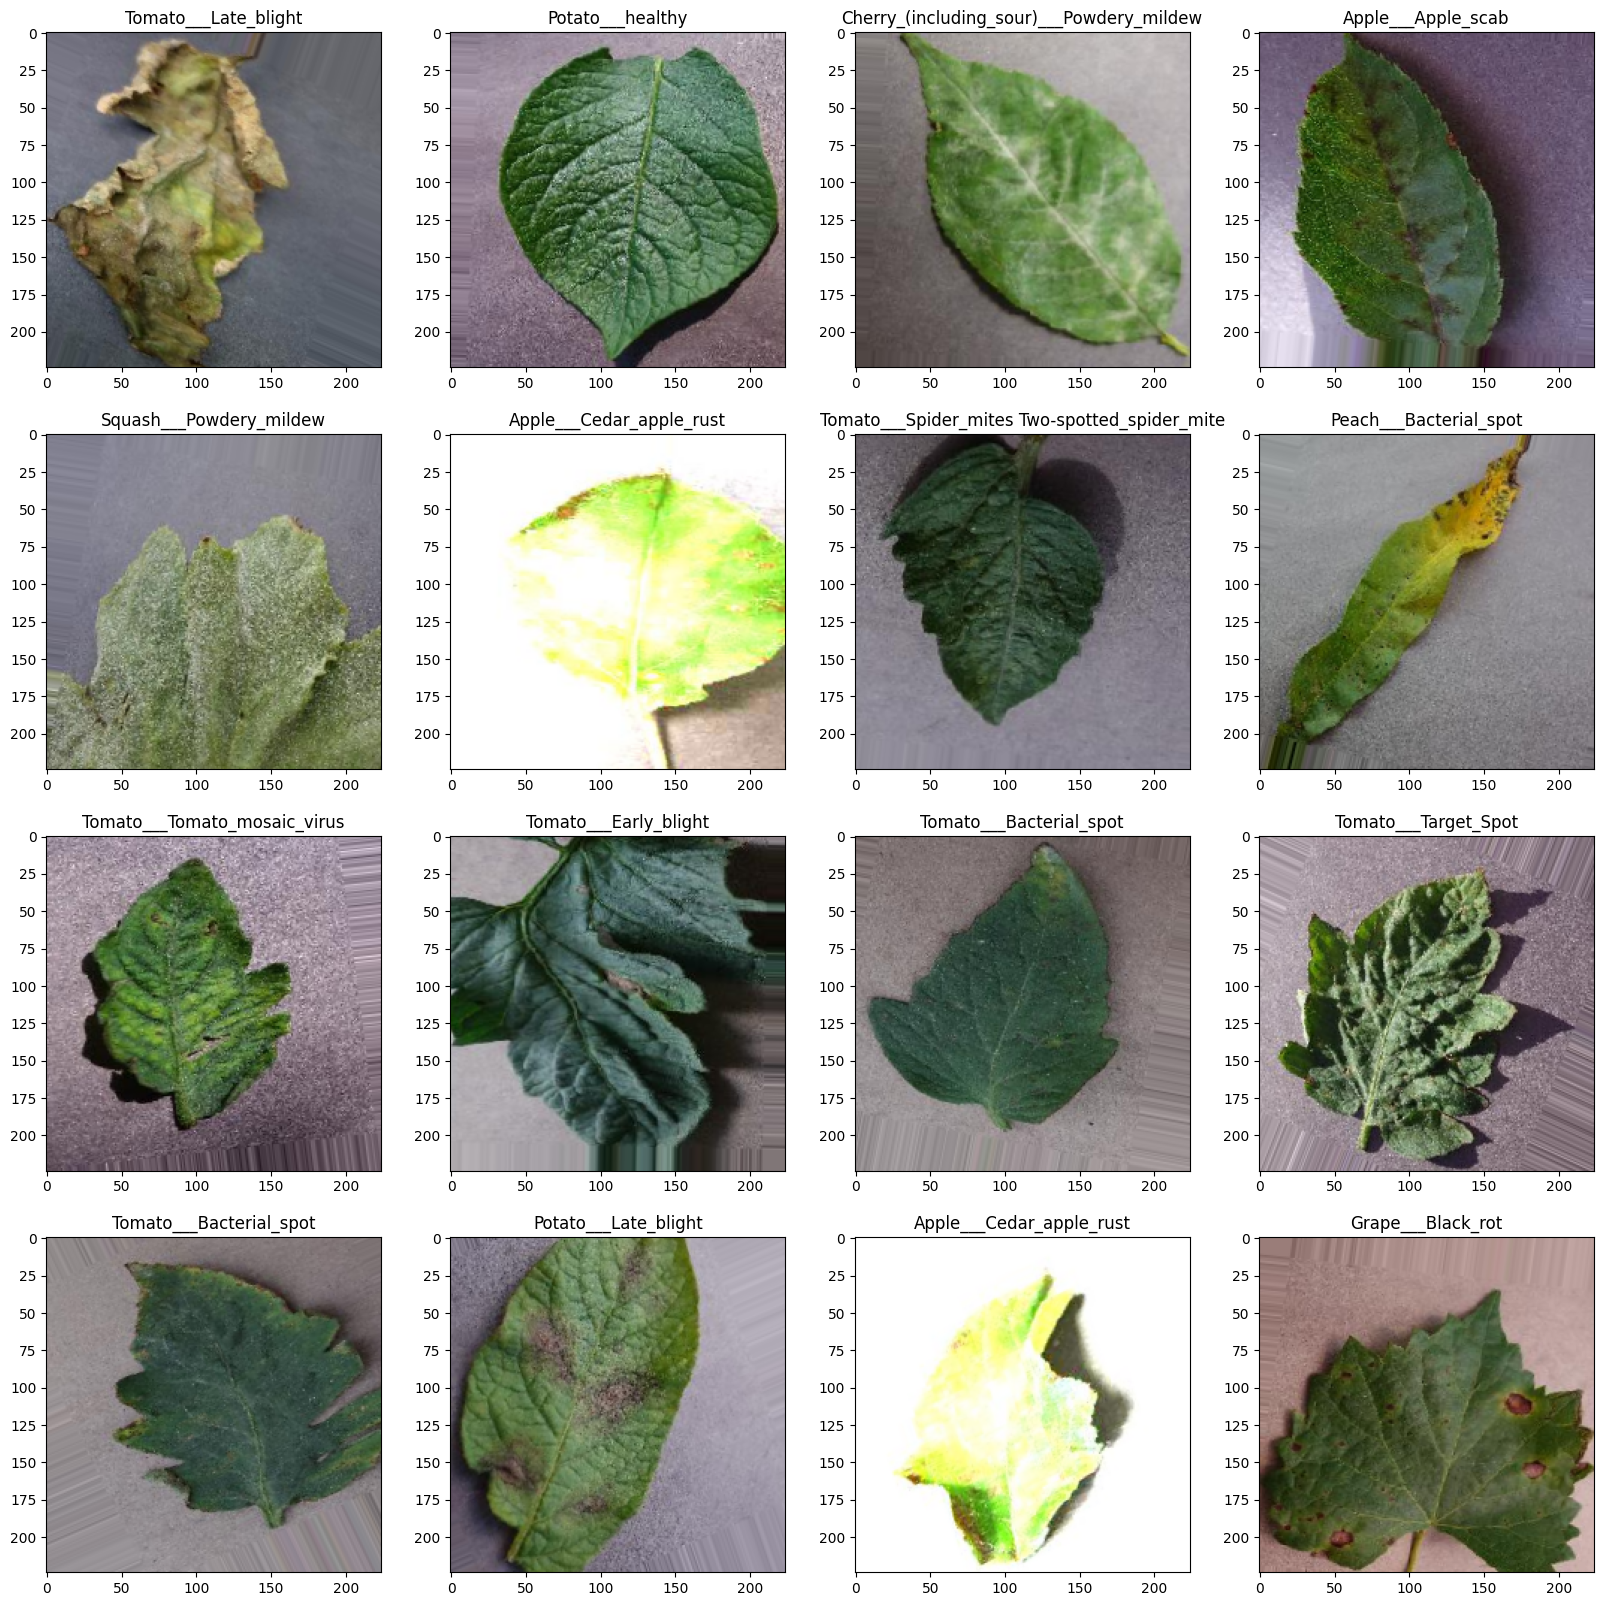

In [ ]:
classes=list(train_generator.class_indices.keys())
plt.figure(figsize=(20,20))
for X_batch, y_batch in train_generator:
    # create a grid of 3x3 images
    for i in range(0,16):
        plt.subplot(4,4,i+1)
        plt.imshow(X_batch[i])
        plt.title(classes[np.where(y_batch[i]==1)[0][0]])
    # show the plot
    plt.show()
    break

In [ ]:
valid_generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
    validation_split=0.1
).flow_from_directory(train_dir,batch_size=16,target_size=(Size,Size),subset='validation',shuffle=False)

Found 7013 images belonging to 38 classes.


In [ ]:
X_test=[]
for folder in os.listdir(test_dir):
    files=gb.glob(test_dir+'/*.JPG')
    for file in files :
        img=cv.imread(file)
        X_test.append(cv.resize(img,(Size,Size)))

In [ ]:
X_test=np.array(X_test)
print(X_test.shape)

(1089, 224, 224, 3)


In [ ]:
X_test=X_test/255.0

In [ ]:
import keras
from keras.layers import Flatten , Dense , Dropout , BatchNormalization , MaxPooling2D ,Conv2D
from keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping ,ReduceLROnPlateau ,ModelCheckpoint

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

EarlyStop = EarlyStopping(patience=10, restore_best_weights=True)
Reduce_LR = ReduceLROnPlateau(monitor='val_accuracy', verbose=2, factor=0.5, min_lr=0.00001)
model_check = ModelCheckpoint('model.keras', monitor='val_loss', verbose=1, save_best_only=True)

callback = [EarlyStop, Reduce_LR, model_check]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
model=Sequential([
                Conv2D(32,3,activation='relu',kernel_initializer='he_normal',input_shape=(Size,Size,3)),
                BatchNormalization(),
                MaxPooling2D(3),

                Conv2D(64,3,activation='relu',kernel_initializer='he_normal'),
                BatchNormalization(),
                MaxPooling2D(3),

                Conv2D(128,3,activation='relu',kernel_initializer='he_normal'),
                BatchNormalization(),
                MaxPooling2D(3),

                Conv2D(256,3,activation='relu',kernel_initializer='he_normal'),
                BatchNormalization(),
                MaxPooling2D(3),
#vgg19(include_top=False,input_shape=(Size,Size,3)),
                Flatten(),
                Dense(512,activation='relu'),
                BatchNormalization(),
                Dropout(0.2),
                BatchNormalization(),
                Dense(256,activation='relu'),
                Dropout(0.2),
                BatchNormalization(),
                Dense(38,activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_generator,validation_data=valid_generator,epochs=10,batch_size=32,
                  steps_per_epoch=len(train_generator)//16,validation_steps=len(valid_generator)//16,
                  callbacks=callback, verbose=1)

Epoch 1/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 900ms/step - accuracy: 0.6292 - loss: 1.1621
Epoch 1: val_loss did not improve from 0.76209
247/247 ━━━━━━━━━━━━━━━━━━━━ 227s 918ms/step - accuracy: 0.6292 - loss: 1.1620 - val_accuracy: 0.4954 - val_loss: 1.8418 - learning_rate: 0.0010
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.6507 - loss: 1.1661
Epoch 2: val_loss did not improve from 0.76209
247/247 ━━━━━━━━━━━━━━━━━━━━ 228s 923ms/step - accuracy: 0.6506 - loss: 1.1663 - val_accuracy: 0.5579 - val_loss: 1.7614 - learning_rate: 0.0010
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - accuracy: 0.6411 - loss: 1.1769
Epoch 3: val_loss did not improve from 0.76209
247/247 ━━━━━━━━━━━━━━━━━━━━ 229s 928ms/step - accuracy: 0.6412 - loss: 1.1766 - val_accuracy: 0.7801 - val_loss: 0.8099 - learning_rate: 0.0010
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.6819 - loss: 1.0390
Epoch 4: val_loss did not improve from 0.76209
247/247 ━━━━━━━━━━━━━━━━━

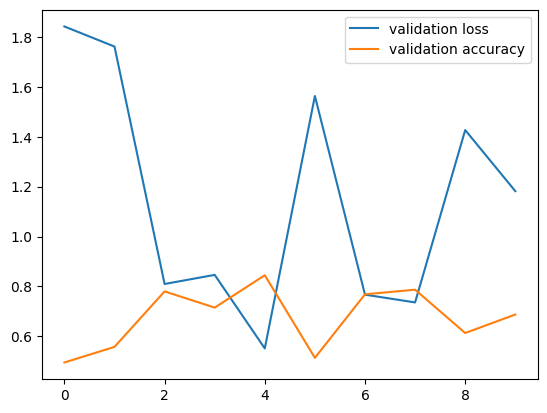

In [ ]:
plt.plot(history.history['val_loss'],label='validation loss')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.legend()

In [ ]:


predictions=model.predict(valid_generator)



439/439 ━━━━━━━━━━━━━━━━━━━━ 72s 164ms/step


In [ ]:


from sklearn.metrics import classification_report
print(classification_report(valid_generator.classes, predictions.argmax(axis=1)))



              precision    recall  f1-score   support

           0       0.66      0.79      0.72       201
           1       0.53      0.93      0.67       198
           2       0.82      0.73      0.77       176
           3       0.88      0.42      0.57       200
           4       0.85      0.51      0.64       181
           5       0.84      0.82      0.83       168
           6       0.50      0.93      0.65       182
           7       0.76      0.68      0.72       164
           8       0.95      0.95      0.95       190
           9       0.87      0.76      0.81       190
          10       0.93      0.93      0.93       185
          11       0.63      0.44      0.52       188
          12       0.71      0.93      0.81       192
          13       1.00      0.48      0.65       172
          14       0.76      0.35      0.48       169
          15       0.74      0.92      0.82       201
          16       0.81      0.60      0.69       183
          17       0.99    

<Axes: >

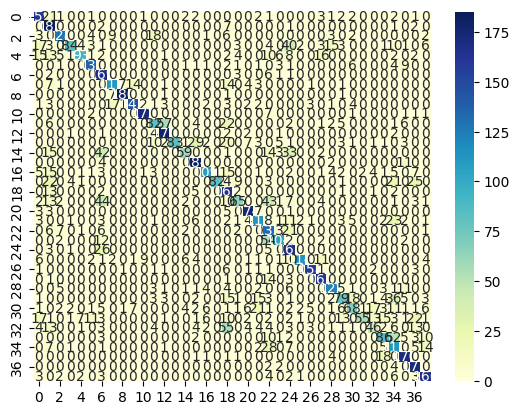

In [ ]:


import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(valid_generator.classes, predictions.argmax(axis=1))
sns.heatmap(cm,  annot=True, fmt="d" ,cmap="YlGnBu")



<Axes: >

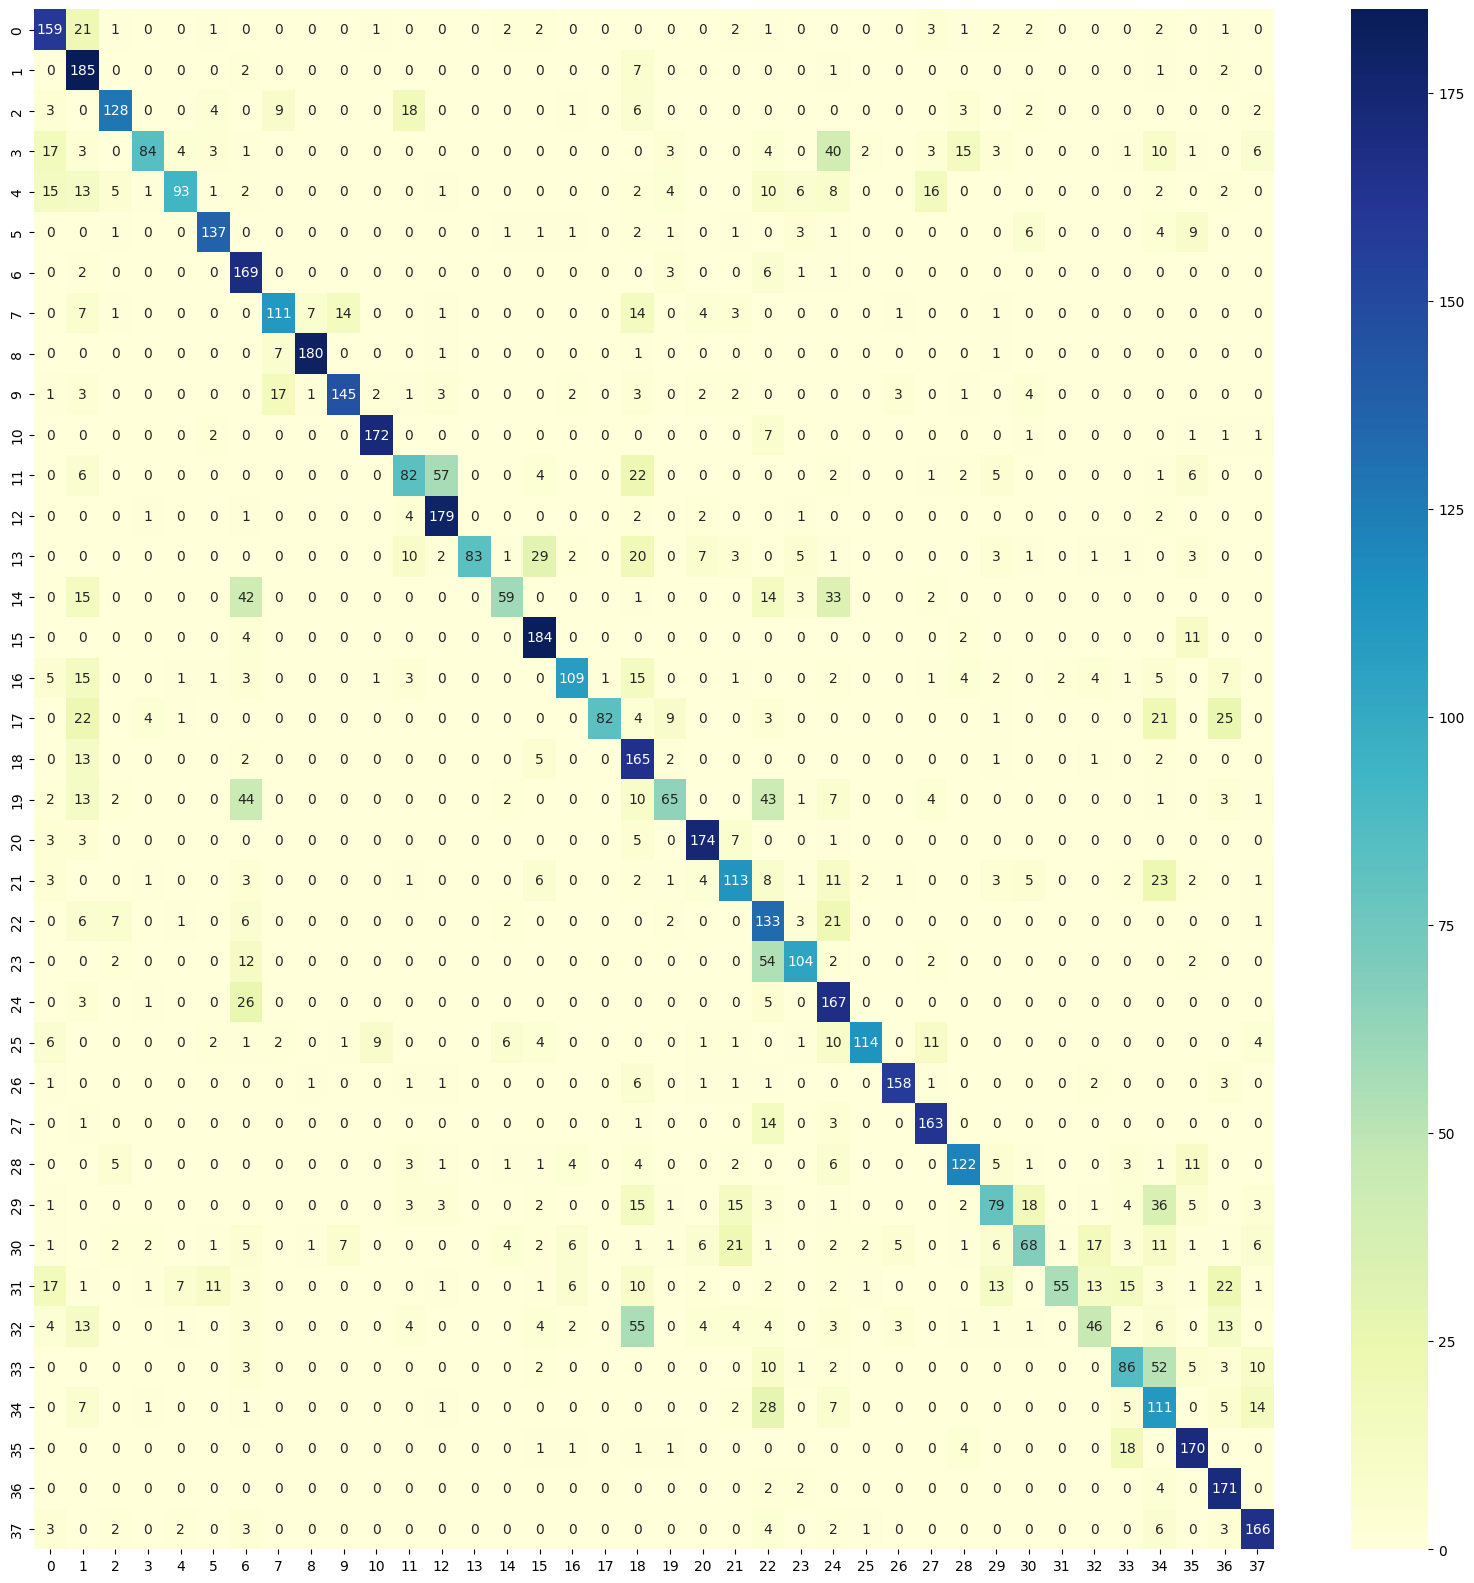

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(cm,  annot=True, fmt="d" ,cmap="YlGnBu")

In [ ]:
y_pred=model.predict(X_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 301ms/step


In [ ]:
y_pred[0]

array([5.32391146e-02, 1.24153681e-04, 6.69440604e-04, 1.17301226e-01,
       1.09181863e-04, 4.19117771e-02, 9.46892487e-06, 5.15903404e-04,
       7.96315799e-05, 8.14624969e-03, 7.86455075e-06, 4.81591269e-05,
       7.37506662e-06, 9.67210071e-05, 4.03294462e-06, 6.13401120e-04,
       1.02263903e-02, 5.80332987e-03, 7.01939134e-05, 1.09019027e-04,
       1.06619566e-03, 1.20424360e-01, 1.67381862e-04, 6.51946550e-07,
       1.08988774e-04, 4.88832034e-03, 6.67901486e-06, 2.76413266e-05,
       3.16164754e-02, 2.12466866e-01, 1.50127441e-01, 1.42390504e-01,
       2.04014755e-03, 2.41652392e-02, 5.89821115e-02, 7.31194275e-04,
       8.02980911e-04, 1.08941896e-02], dtype=float32)

In [ ]:
predictions=y_pred.argmax(axis=1)

In [ ]:
classes

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [ ]:
predictions

array([29, 12, 19, ..., 24, 22, 36])

In [ ]:
predictions[0]

29

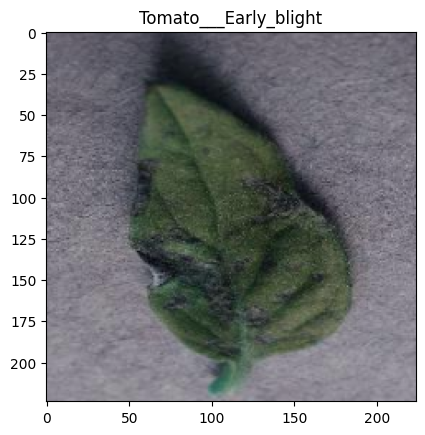

In [ ]:


plt.imshow(X_test[0])
plt.title(classes[predictions[0]])
plt.show()

